# Two-channel FRET efficiency analysis from binary cell masks

This notebook performs per-cell FRET efficiency analysis from two fluorescence imaging channels and a binary cell segmentation mask. The workflow is designed for experiments in which the same cells are imaged in a donor/Turquoise channel (`ch1`) and a FRET/acceptor-emission channel (`ch3`), together with a segmentation mask generated from a neural-network or other segmentation workflow.

The binary mask is first refined into individual cell instances using watershed-based separation of connected regions. Background fluorescence is then estimated from non-cell pixels and subtracted independently from both channels to reduce contributions from diffuse signal and uneven illumination.

Using the corrected donor and FRET images, the notebook applies bleed-through and calibration corrections to compute pixel-wise and per-cell FRET efficiency values. For each segmented cell, the mean FRET efficiency is extracted and stored together with positional and morphological information.

The final outputs include segmentation previews, a per-cell FRET efficiency table, and pseudocolor FRET efficiency maps that can be used for visualization, quantitative analysis, and figure generation.

## Requirements

This notebook requires Python 3.9+ and the following packages:

```bash
pip install numpy pandas tifffile matplotlib scipy scikit-image

In [8]:
import os
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from scipy import ndimage as ndi
from skimage import morphology, measure, segmentation
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

### User settings

This section defines the input files, output directory, segmentation settings, background subtraction options, and FRET correction constants used for the analysis. The user should update the file paths to match the donor image, FRET/acceptor image, and binary segmentation mask generated by the neural-network or segmentation workflow.

Segmentation parameters control how the binary mask is separated into individual cell instances and slightly shrunk to reduce edge-related noise. Background subtraction can be enabled to correct fluorescence values using non-cell pixels surrounding the segmented regions.

The FRET efficiency calculation uses user-defined correction factors for bleed-through, intensity scaling, quantum-yield ratio, spectral sensitivity, and detection gain. These constants should be adjusted if different sensors, optical settings, or calibration values are used.

Pseudo-color settings define the display range and color map used to visualize the final per-cell FRET efficiency output.

In [2]:
#File paths to be chnaged if needed. The code assumes the input images are in the same directory as the script.

DONOR_IMAGE_PATH = "example_image&mask/donor.tif" # Donor/Turquoise channel, e.g. CFP/Turquoise
FRET_IMAGE_PATH = "example_image&mask/acceptor.tif" # FRET channel, e.g. YFP/FRET emission
BINARY_MASK_PATH = "example_image&mask/binary_mask.tif" # Binary mask from neural-network output.

OUT_DIR = "FRET_analysis_output"
os.makedirs(OUT_DIR, exist_ok=True)

OUTPUT_CSV = os.path.join(OUT_DIR, "cell_FRET_efficiency.csv")
OUTPUT_SEGMENTATION_PREVIEW = os.path.join(OUT_DIR, "segmentation_preview.tif")
OUTPUT_PSEUDOCOLOR = os.path.join(OUT_DIR,"EFRET_per_cell_pseudocolor.tif")
OUTPUT_COLORBAR = os.path.join(OUT_DIR,"EFRET_color_scale_bar.tif")

#Segmentation parameters
WATERSHED_MIN_DISTANCE = 8
MIN_CELL_SIZE = 40
PEAK_THRESH = 0.15
SHRINK_FACTOR = 0.95 #  Shrink to remove the noise from the edge (1.0 = no shrinkage)

#Background subtraction parameters
DO_BACKGROUND_SUBTRACTION = True
BACKGROUND_KEEP_FRACTION = 0.95  # Fraction of background pixels to keep (keep 0.95 farthest one and remove 0.05 closest one to cell boundaries).
# Background is estimated from non-cell pixels.
# 50 = median background.
BACKGROUND_PERCENTILE = 50

# FRET efficiency calculation parameters. 

# Formula used here follows the original analysis:
#
#   I_Turq = I_Turq_raw * C
#   I_FRET = I_FRET_raw * D
#   FRET_corr = (1 - A) * I_FRET - B * I_Turq
#   D_lost = FRET_corr * QYd_QYa_ratio * Sd_Sa_ratio * Gd_Ga_ratio
#   E_FRET = D_lost / (D_lost + I_Turq)
#
# A and B are the two bleed-through correction terms.

A = 0.016
B = 0.11
C = 1.0
D = 1.0
QYd_QYa_ratio = 1.474
Sd_Sa_ratio = 1.0
Gd_Ga_ratio = 1.0

#Pseudocolor parameters for visualization
EFRET_VMIN = 0.7
EFRET_VMAX = 1.0
EFRET_CMAP = "coolwarm"

### Import helper functions

This section imports the helper functions used throughout the FRET analysis workflow. These functions are stored in `FRET_analysis_functions/fret_utils.py` and include tools for loading images and masks, refining binary masks into individual cell labels, performing background subtraction, calculating FRET efficiency, and generating segmentation previews and pseudocolor outputs.

In [3]:
from FRET_analysis_functions.fret_utils import ( # type: ignore
    load_image_as_float,
    load_binary_mask,
    normalize_for_display,
    refine_to_instances,
    shrink_binary_mask,
    shrink_background_mask_from_cells,
    apply_background_subtraction,
    apply_background_subtraction_from_cell_mask,
    calculate_fret_efficiency,
    make_segmentation_preview,
    make_background_preview,
    save_per_cell_pseudocolor_and_labeled_colorbar,
)

### Load images and binary mask

This step loads the donor and FRET fluorescence images together with the binary segmentation mask used for cell extraction. The script verifies that the donor and FRET images have matching dimensions before continuing the analysis, ensuring that pixel-wise calculations can be performed correctly.

The binary mask is automatically resized if needed to match the image dimensions. Basic information about image size, datatype, and mask coverage is printed as an initial quality-control step before segmentation refinement and FRET quantification.

In [4]:
I_Turq_raw = load_image_as_float(DONOR_IMAGE_PATH)
I_FRET_raw = load_image_as_float(FRET_IMAGE_PATH)

if I_Turq_raw.shape != I_FRET_raw.shape:
    raise ValueError(
        f"Donor and FRET images have different shapes: "
        f"{I_Turq_raw.shape} vs {I_FRET_raw.shape}"
    )

binary_mask = load_binary_mask(BINARY_MASK_PATH, target_shape=I_Turq_raw.shape)

print("Donor/Turquoise image:", I_Turq_raw.shape, I_Turq_raw.dtype)
print("FRET image:", I_FRET_raw.shape, I_FRET_raw.dtype)
print("Binary mask:", binary_mask.shape, binary_mask.dtype)
print("Mask pixels:", int(binary_mask.sum()))

Donor/Turquoise image: (300, 300) float32
FRET image: (300, 300) float32
Binary mask: (300, 300) uint8
Mask pixels: 5468


###  Binary mask to watershed cell instances

This step converts the binary cell mask into individual cell labels. Watershed segmentation is used to separate connected regions into single-cell instances, and very small objects are removed based on the selected minimum cell size.

The number of detected cells is printed, and a segmentation preview is saved with cell outlines and labels overlaid on the donor image. This preview should be checked before continuing to background subtraction and FRET quantification.

Detected cells after watershed: 38


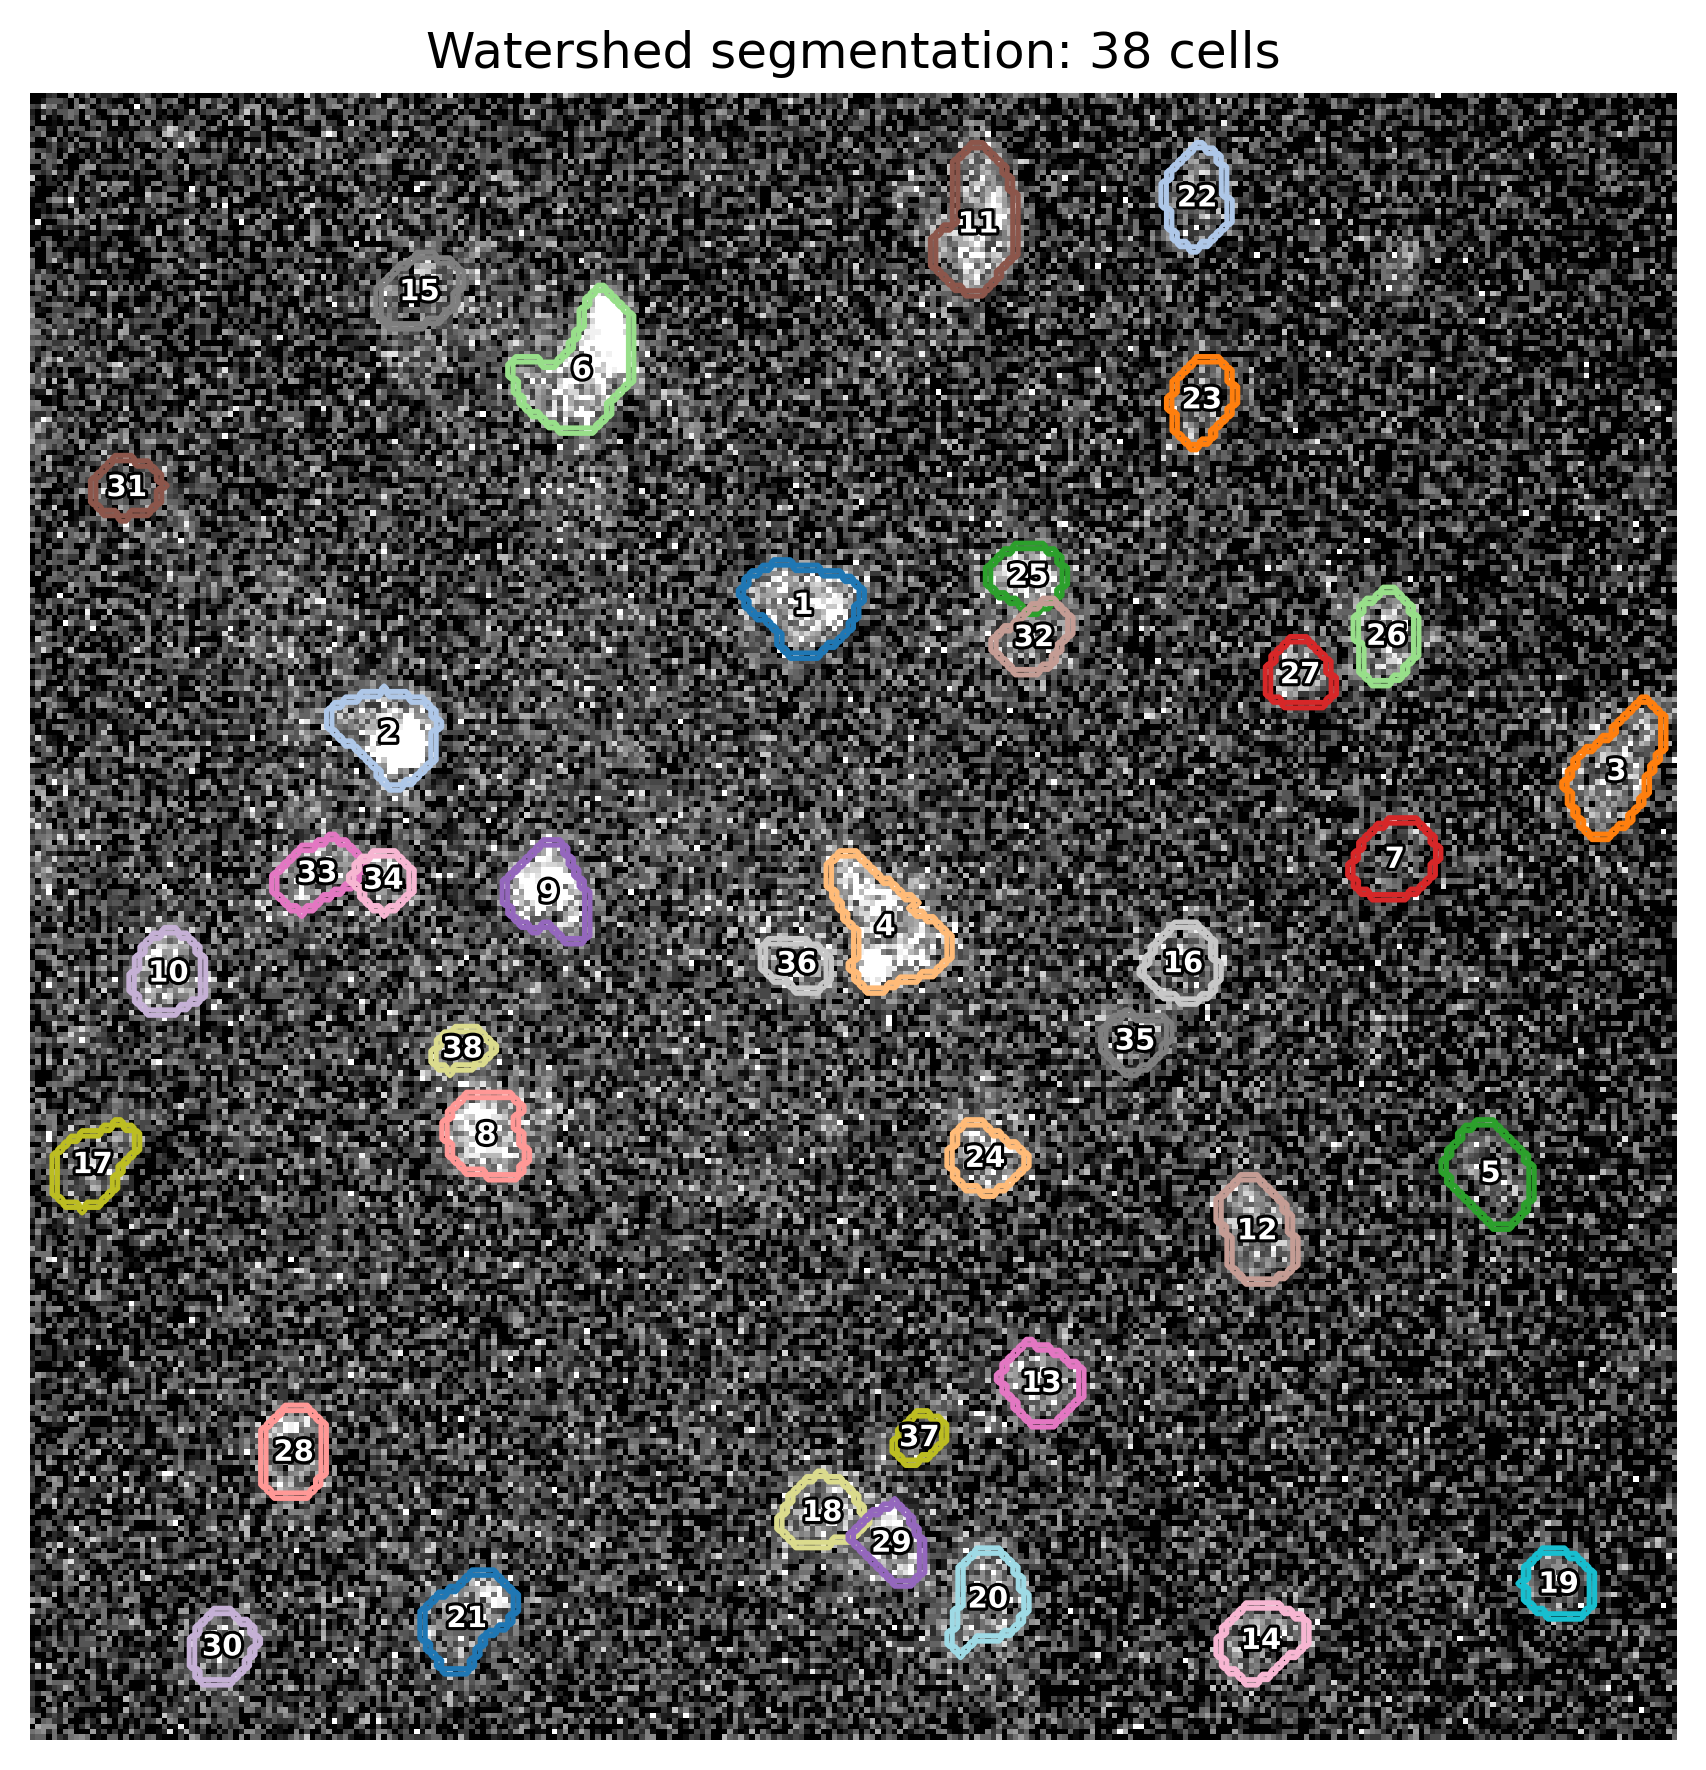

Saved segmentation preview to: FRET_analysis_output/segmentation_preview.tif


In [5]:
labels = refine_to_instances(
    binary_mask,
    min_distance=WATERSHED_MIN_DISTANCE,
    min_size=MIN_CELL_SIZE,
    peak_thresh=PEAK_THRESH
)

n_cells = int(labels.max())
print(f"Detected cells after watershed: {n_cells}")

make_segmentation_preview(
    base_img=I_Turq_raw,
    labels=labels,
    output_path=OUTPUT_SEGMENTATION_PREVIEW
)

print(f"Saved segmentation preview to: {OUTPUT_SEGMENTATION_PREVIEW}")

### Background subtraction and per-cell FRET calculation

This step performs background correction and calculates FRET efficiency for each segmented cell. Background is estimated from non-cell pixels defined by the original binary mask, excluding pixels close to cell boundaries to reduce contamination from edge signal or fluorescence halos.

After background subtraction, pixel-wise FRET efficiency is calculated from the corrected donor and FRET images using the specified correction factors. For each watershed-labeled cell, the mask is slightly shrunk to minimize edge-related noise, and the mean FRET efficiency is extracted from the shrunken region.

The final output is a per-cell CSV table containing cell ID, centroid position, cell area, mean FRET efficiency, and the correction parameters used for the calculation.

In [6]:
# Background subtraction is done using the original binary mask to define cell vs non-cell regions.

cell_mask_for_background = binary_mask > 0

if DO_BACKGROUND_SUBTRACTION:
    donor_bg, I_Turq_corr, background_mask = apply_background_subtraction_from_cell_mask(
        channel_img=I_Turq_raw,
        cell_mask=cell_mask_for_background,
        keep_fraction=BACKGROUND_KEEP_FRACTION,
        percentile=BACKGROUND_PERCENTILE,
        min_size=20
    )

    fret_bg, I_FRET_corr, _ = apply_background_subtraction_from_cell_mask(
        channel_img=I_FRET_raw,
        cell_mask=cell_mask_for_background,
        keep_fraction=BACKGROUND_KEEP_FRACTION,
        percentile=BACKGROUND_PERCENTILE,
        min_size=20
    )

else:
    donor_bg = 0.0
    fret_bg = 0.0
    I_Turq_corr = I_Turq_raw.copy()
    I_FRET_corr = I_FRET_raw.copy()
    background_mask = ~cell_mask_for_background

# Calculate pixel-wise FRET efficiency maps using the background-subtracted images

E_FRET, FRET_corr, D_lost = calculate_fret_efficiency(
    I_Turq_corr,
    I_FRET_corr,
    A, B, C, D,
    QYd_QYa_ratio, Sd_Sa_ratio, Gd_Ga_ratio
)

rows_out = []
values_by_label = {}

for prop in measure.regionprops(labels):
    cell_id = int(prop.label)

    mask = labels == cell_id
    shrunken = shrink_binary_mask(mask, SHRINK_FACTOR)

    if np.count_nonzero(shrunken) == 0:
        continue

    mean_EFRET = float(np.nanmean(E_FRET[shrunken]))
    if not np.isfinite(mean_EFRET):
        continue

    mean_ch1_raw = float(np.mean(I_Turq_raw[shrunken]))
    mean_ch3_raw = float(np.mean(I_FRET_raw[shrunken]))

    mean_ch1_bgsub = float(np.mean(I_Turq_corr[shrunken]))
    mean_ch3_bgsub = float(np.mean(I_FRET_corr[shrunken]))

    mean_FRET_corr = float(np.mean(FRET_corr[shrunken]))
    mean_D_lost = float(np.mean(D_lost[shrunken]))

    centroid_y, centroid_x = prop.centroid

    rows_out.append({
        "cell_id": cell_id,
        "centroid_y": float(centroid_y),
        "centroid_x": float(centroid_x),
        "area_px": int(prop.area),
        "mean_FRET": mean_EFRET,

        "A": A,
        "B": B,
        "C": C,
        "D": D,
        "QYd_QYa_ratio": QYd_QYa_ratio,
        "Sd_Sa_ratio": Sd_Sa_ratio,
        "Gd_Ga_ratio": Gd_Ga_ratio
    })

    values_by_label[cell_id] = mean_EFRET

df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False)

print(f"Saved per-cell FRET efficiency CSV to: {OUTPUT_CSV}")
print(f"Analyzed cells: {len(df_out)}")

Saved per-cell FRET efficiency CSV to: FRET_analysis_output/cell_FRET_efficiency.csv
Analyzed cells: 38


### Pseudocolor FRET visualization

This step generates the final per-cell pseudocolor image. Each segmented cell is colored according to its mean FRET efficiency value, using the selected display range and colormap.

The output includes a pseudocolor TIFF image and a separate labeled colorbar TIFF, which can be used for visualization, figure preparation, and comparison across samples.

In [7]:
per_cell_img, pseudocolor_rgb, colorbar_rgb = save_per_cell_pseudocolor_and_labeled_colorbar(
    labels=labels,
    values_by_label=values_by_label,
    pseudocolor_output_path=OUTPUT_PSEUDOCOLOR,
    colorbar_output_path=OUTPUT_COLORBAR,
    vmin=EFRET_VMIN,
    vmax=EFRET_VMAX,
    cmap_name=EFRET_CMAP,
    colorbar_label="FRET efficiency",
    colorbar_ticks=np.linspace(EFRET_VMIN, EFRET_VMAX, 4)
)

print(f"Saved pseudocolor image to: {OUTPUT_PSEUDOCOLOR}")

Saved pseudocolor TIFF to: FRET_analysis_output/EFRET_per_cell_pseudocolor.tif
Saved labeled colorbar TIFF to: FRET_analysis_output/EFRET_color_scale_bar.tif
Saved pseudocolor image to: FRET_analysis_output/EFRET_per_cell_pseudocolor.tif
